# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
df = pd.read_csv("cancer.csv") 
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [3]:
df.shape

(699, 11)

In [4]:
df = df.drop_duplicates()

In [5]:
df.shape

(691, 11)

In [6]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null object
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(10), object(1)
memory usage: 64.8+ KB


In [8]:
df.shape

(691, 11)

In [9]:
df.describe(include="all")

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.910000e+02,691.000000,691.000000,691.000000,691.000000,691.000000,691,691.000000,691.000000,691.000000,691.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,397,NaN,NaN,NaN,NaN
mean,1.073333e+06,4.426918,3.130246,3.201158,2.824891,3.211288,NaN,3.435601,2.882779,1.593343,2.688857
std,6.192953e+05,2.815861,3.041328,2.959886,2.866552,2.199852,NaN,2.442345,3.066298,1.723129,0.951051
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,2.000000
25%,8.725490e+05,2.000000,1.000000,1.000000,1.000000,2.000000,NaN,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,NaN,3.000000,1.000000,1.000000,2.000000
75%,1.238437e+06,6.000000,5.000000,5.000000,4.000000,4.000000,NaN,5.000000,4.000000,1.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [10]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [11]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [12]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [13]:
df[df['Bare Nuclei'] == "?"].count()

ID                             16
ClumpThickness                 16
Cell Size                      16
Cell Shape                     16
Marginal Adhesion              16
Single Epithelial Cell Size    16
Bare Nuclei                    16
Normal Nucleoli                16
Bland Chromatin                16
Mitoses                        16
Class                          16
dtype: int64

In [14]:
df = df.replace('?', np.nan)
df = df.apply(lambda x: x.fillna(x.median()),axis=0)


# converting the hp column from object 'Bare Nuclei'/ string type to float
df['Bare Nuclei'] = df['Bare Nuclei'].astype('int64') 

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null int64
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(11)
memory usage: 64.8 KB


In [16]:
df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [17]:
# Check for correlation of variable


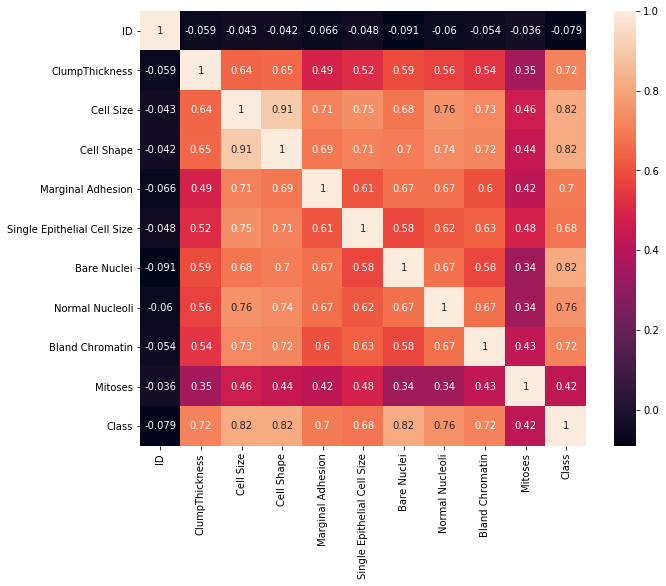

In [18]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)

In [19]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [20]:
#Let us check for pair plots

/Applications/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
/Applications/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/Applications/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/Applications/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwa

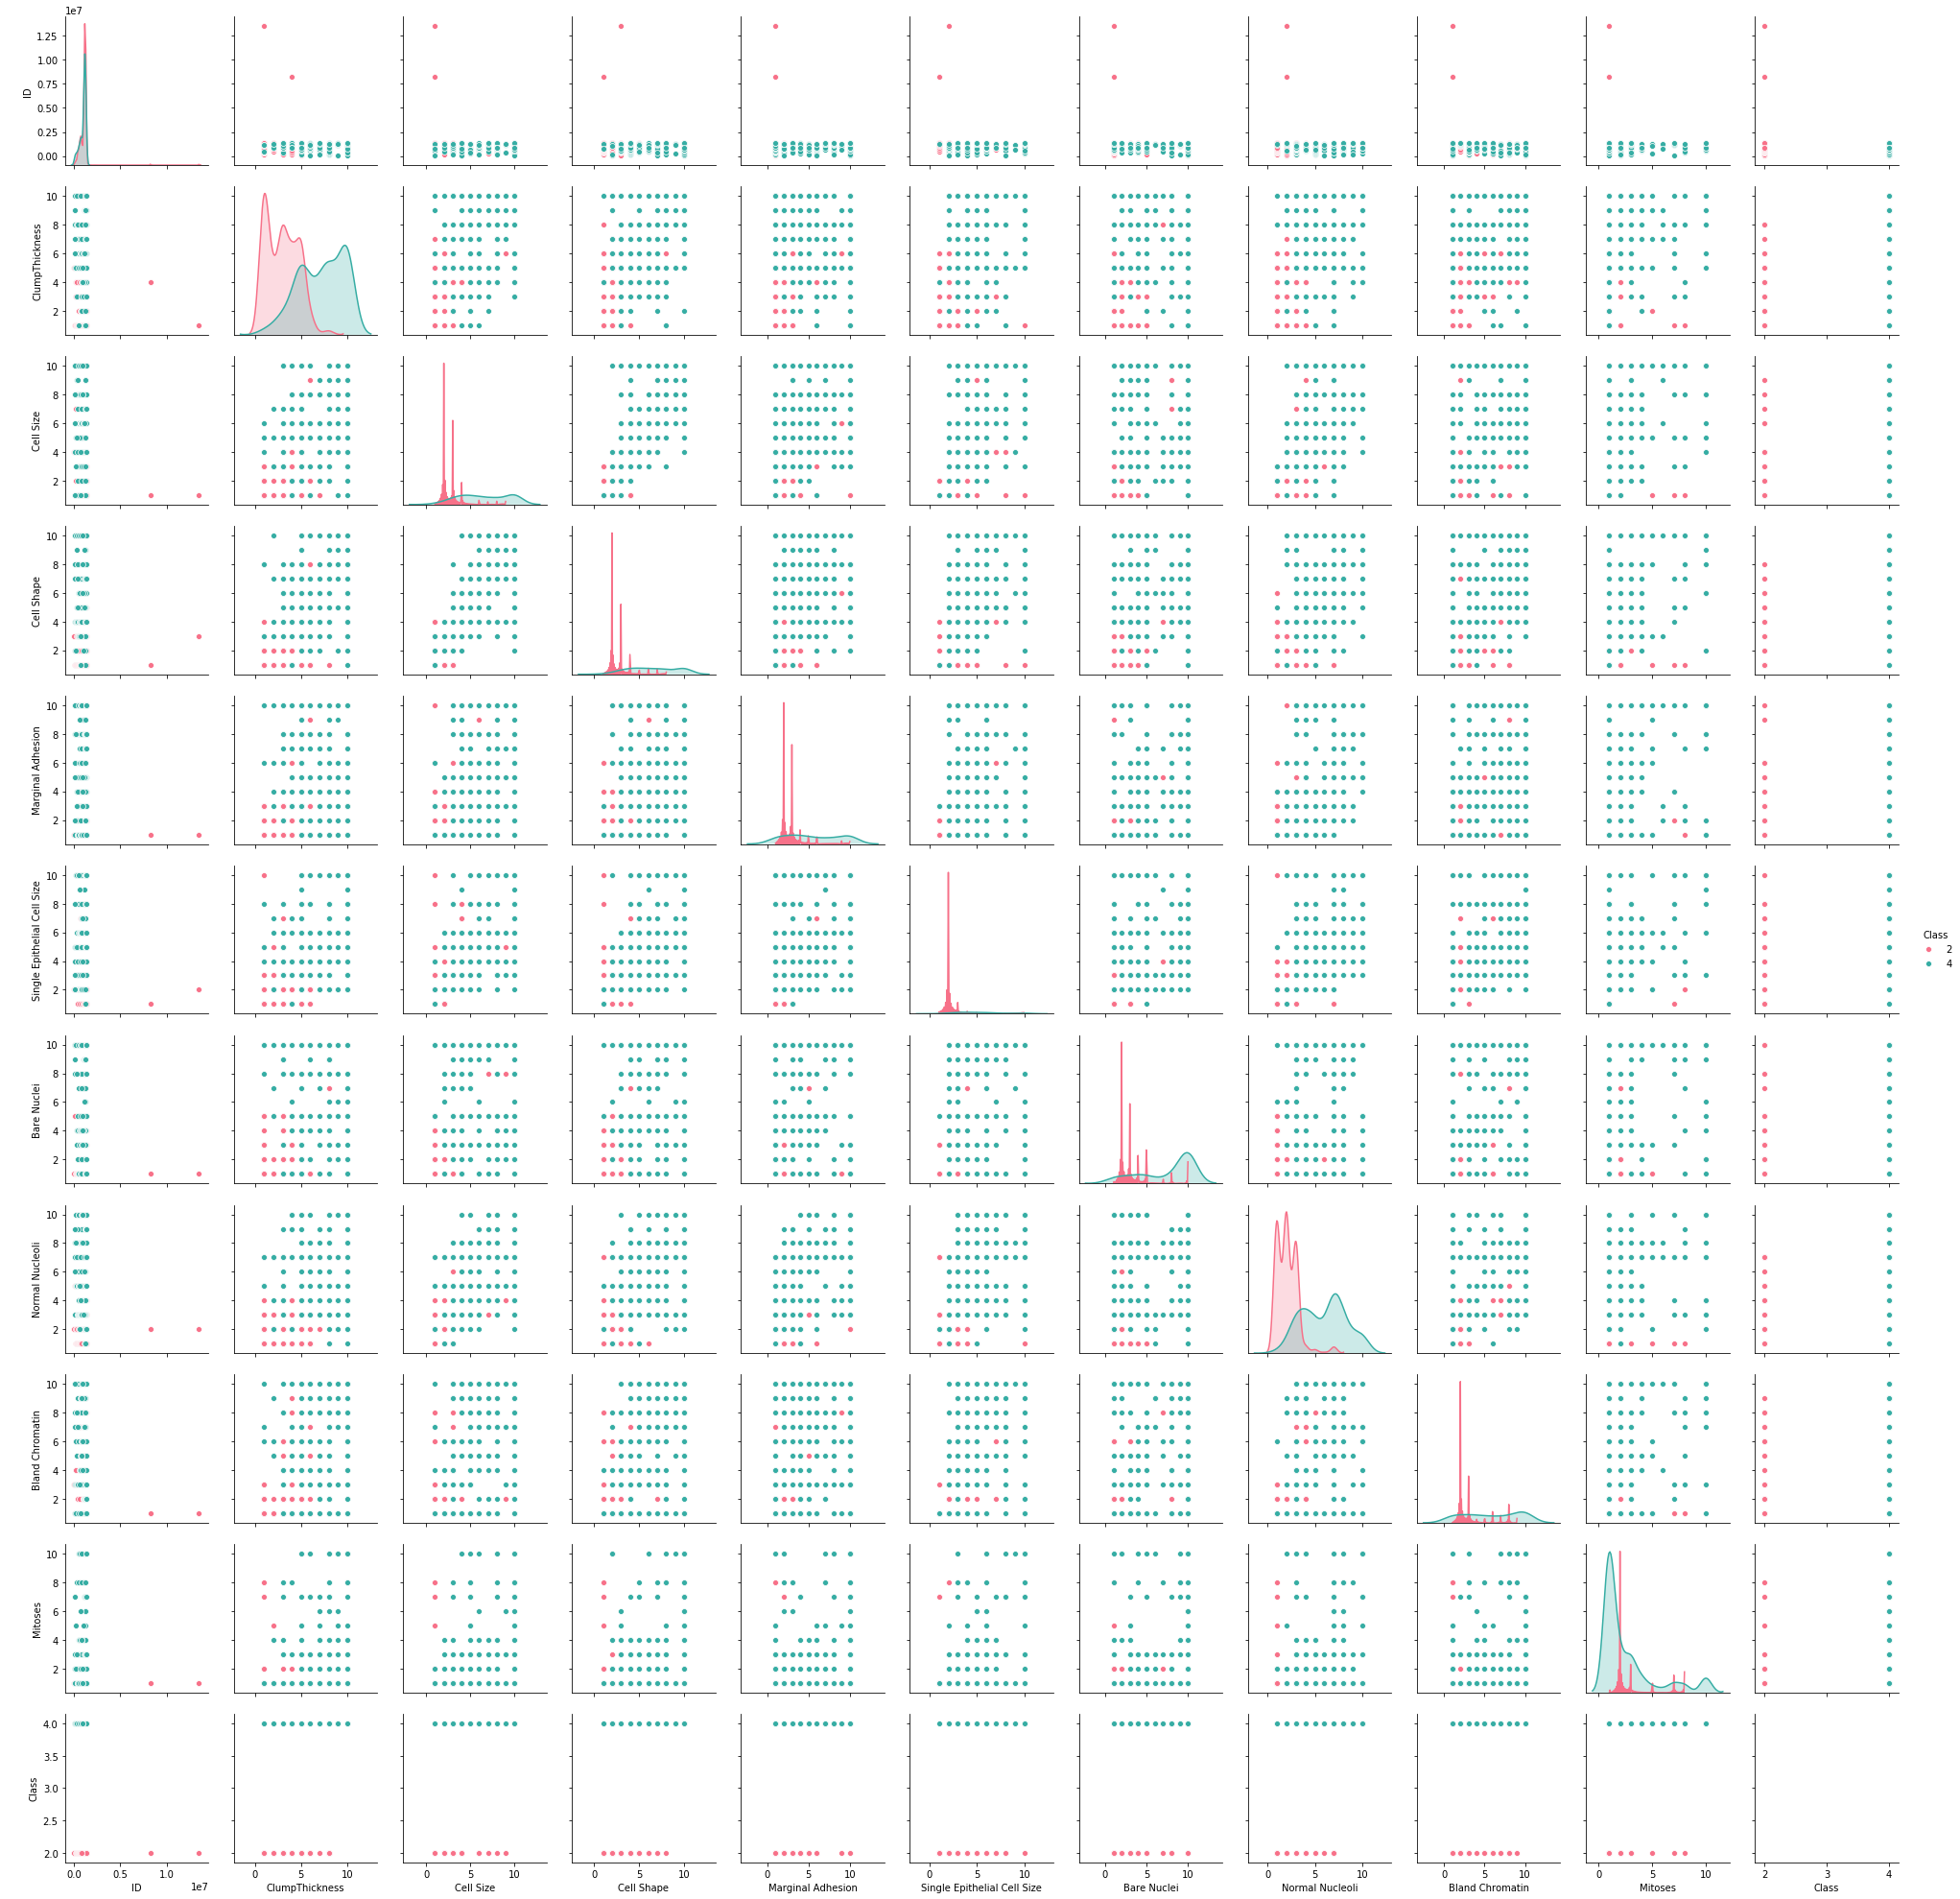

In [21]:
sns.pairplot(df,hue="Class", palette="husl")

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [22]:
# We could see most of the outliers are now removed.

In [23]:
df = df.drop('ID',axis=1)
# Removing ID column as it is not usefull

# I am not removing the outlier as it is deleting too much data around 25% of data which will impact the  result hence considering as it as Extreme values

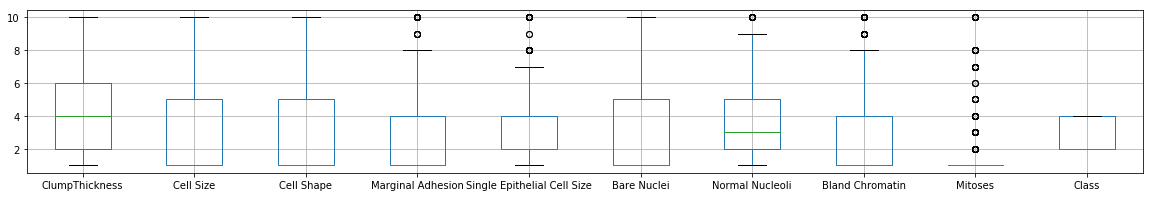

In [24]:
df.boxplot(figsize=[20,3])

In [25]:
# Standardize Columns
from scipy.stats import zscore
numeric_cols = df.drop('Class', axis=1)
class_type  = df.pop("Class")
numeric_cols = numeric_cols.apply(zscore)
df = numeric_cols.join(class_type)   


In [26]:
df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,0.203667,-0.700940,-0.744202,-0.637077,-0.551021,-0.686127,-0.178483,-0.614468,-0.34459,2
1,0.203667,0.286185,0.270085,0.759339,1.723505,1.804838,-0.178483,-0.288106,-0.34459,2
2,-0.507110,-0.700940,-0.744202,-0.637077,-0.551021,-0.409353,-0.178483,-0.614468,-0.34459,2
3,0.559055,1.602353,1.622467,-0.637077,-0.096116,0.144195,-0.178483,1.343706,-0.34459,2
4,-0.151722,-0.700940,-0.744202,0.061131,-0.551021,-0.686127,-0.178483,-0.614468,-0.34459,2


# Q6 Create a covariance matrix for identifying Principal components

In [27]:
# PCA
# Step 1 - Create covariance matrix


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X_std = StandardScaler().fit_transform(df)
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00144928 0.64427196 0.65469961 0.48865637 0.51819771 0.59169728
  0.56188952 0.53648819 0.35086138 0.7179775 ]
 [0.64427196 1.00144928 0.90673173 0.71415051 0.74819397 0.68578334
  0.760626   0.72829333 0.46073106 0.81890491]
 [0.65469961 0.90673173 1.00144928 0.69199047 0.71542879 0.7054026
  0.73952487 0.72574349 0.44123095 0.8188784 ]
 [0.48865637 0.71415051 0.69199047 1.00144928 0.60935911 0.67369366
  0.67078345 0.6033266  0.41777184 0.7023873 ]
 [0.51819771 0.74819397 0.71542879 0.60935911 1.00144928 0.58155073
  0.62141694 0.63497707 0.48334351 0.68221993]
 [0.59169728 0.68578334 0.7054026  0.67369366 0.58155073 1.00144928
  0.67366165 0.57925498 0.34351675 0.81797039]
 [0.56188952 0.760626   0.73952487 0.67078345 0.62141694 0.67366165
  1.00144928 0.67002891 0.34431924 0.75771481]
 [0.53648819 0.72829333 0.72574349 0.6033266  0.63497707 0.57925498
  0.67002891 1.00144928 0.42826329 0.71657711]
 [0.35086138 0.46073106 0.44123095 0.41777184 0.48334351 0.

# Q7 Identify eigen values and eigen vector

In [29]:
# Step 2- Get eigen values and eigen vector

In [30]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.28594386 -0.15822652  0.81819504  0.02247707  0.16839258 -0.09740708
   0.02399121  0.27064219  0.30031774 -0.14626833]
 [-0.35554273 -0.01506343 -0.08186888  0.74153894 -0.00519494 -0.20689509
   0.12876553 -0.45284183  0.20453103  0.102314  ]
 [-0.35258343 -0.0530098  -0.02478914 -0.64549863  0.20447251 -0.19065306
   0.08543557 -0.59007122  0.13272726  0.06583689]
 [-0.31119475 -0.01417964 -0.38033928 -0.04539421 -0.01916057  0.4862085
   0.00883995  0.16127468  0.53868075 -0.45078566]
 [-0.31122679  0.20846124 -0.19375843 -0.06380737  0.01811469 -0.31892242
   0.70915403  0.39983637 -0.21935271 -0.0717235 ]
 [-0.31653835 -0.24728187  0.06189079  0.1129177   0.40302253  0.54397873
   0.05414084 -0.07769035 -0.59559162 -0.0061527 ]
 [-0.32416678 -0.19369696 -0.22095535 -0.05272619  0.07593682 -0.01804264
  -0.25481088  0.3947641   0.17234083  0.74110424]
 [-0.31366951  0.05269479 -0.17996796  0.03243582  0.11136872 -0.45237692
  -0.6133675   0.14193235 -0.27547

In [31]:
eigenvalues, eigenvectors, = np.linalg.eig(cov_matrix)

# eigenvectors is a 8x8 matrix
print('Eigenvectors of Cov(X): \n%s' %eigenvectors)

# eigenvalues is a 8x1 vector
print('\nEigenvalues of Cov(X): \n%s' %eigenvalues)

Eigenvectors of Cov(X): 
[[-0.28594386 -0.15822652  0.81819504  0.02247707  0.16839258 -0.09740708
   0.02399121  0.27064219  0.30031774 -0.14626833]
 [-0.35554273 -0.01506343 -0.08186888  0.74153894 -0.00519494 -0.20689509
   0.12876553 -0.45284183  0.20453103  0.102314  ]
 [-0.35258343 -0.0530098  -0.02478914 -0.64549863  0.20447251 -0.19065306
   0.08543557 -0.59007122  0.13272726  0.06583689]
 [-0.31119475 -0.01417964 -0.38033928 -0.04539421 -0.01916057  0.4862085
   0.00883995  0.16127468  0.53868075 -0.45078566]
 [-0.31122679  0.20846124 -0.19375843 -0.06380737  0.01811469 -0.31892242
   0.70915403  0.39983637 -0.21935271 -0.0717235 ]
 [-0.31653835 -0.24728187  0.06189079  0.1129177   0.40302253  0.54397873
   0.05414084 -0.07769035 -0.59559162 -0.0061527 ]
 [-0.32416678 -0.19369696 -0.22095535 -0.05272619  0.07593682 -0.01804264
  -0.25481088  0.3947641   0.17234083  0.74110424]
 [-0.31366951  0.05269479 -0.17996796  0.03243582  0.11136872 -0.45237692
  -0.6133675   0.14193235 -

# Q8 Find variance and cumulative variance by each eigen vector

In [32]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(6.73517443128564, array([-0.28594386, -0.35554273, -0.35258343, -0.31119475, -0.31122679,
       -0.31653835, -0.32416678, -0.31366951, -0.21025624, -0.3548651 ])), (0.7939207977437867, array([-0.15822652, -0.01506343, -0.0530098 , -0.01417964,  0.20846124,
       -0.24728187, -0.19369696,  0.05269479,  0.89598124, -0.15506231])), (0.5504755964545373, array([ 0.81819504, -0.08186888, -0.02478914, -0.38033928, -0.19375843,
        0.06189079, -0.22095535, -0.17996796,  0.18593899,  0.14637644])), (0.4720201338713168, array([-0.09740708, -0.20689509, -0.19065306,  0.4862085 , -0.31892242,
        0.54397873, -0.01804264, -0.45237692,  0.24281211,  0.11578639])), (0.3710858390818968, array([ 0.02399121,  0.12876553,  0.08543557,  0.00883995,  0.70915403,
        0.05414084, -0.25481088, -0.6133675 , -0.16421613, -0.03899487])), (0.31367446524584813, array([ 0.30031774,  0.20453103,  0.13272726,  0.53868075, -0.21935271,
       -0.59559162,  0.17234083, -0.27547439, -0.02614138, -0.22598

In [33]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%

In [34]:
print(var_explained)

[0.6725427435003032, 0.07927718530292521, 0.05496789602802185, 0.047133703671665535, 0.037054881181839215, 0.03132205224596749, 0.029319962170163475, 0.0263950377900253, 0.013012266351201675, 0.00897427175788711]


In [35]:
print(cum_var_exp)

[0.67254274 0.75181993 0.80678782 0.85392153 0.89097641 0.92229846
 0.95161842 0.97801346 0.99102573 1.        ]


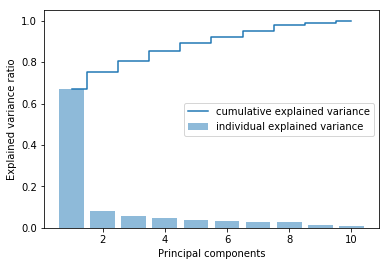

In [36]:
plt.bar(range(1,11), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,11),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(X_std)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2','PC3','PC4','PC5'])

In [38]:
principalDf.head()

,PC1,PC2,PC3,PC4,PC5
0,-1.620572,-0.112542,0.528928,0.126596,-0.075264
1,1.121320,-0.325602,-0.453418,-0.636741,1.698516
2,-1.736205,-0.068520,-0.035497,-0.093198,-0.077332
3,1.153043,-0.336234,0.183308,1.668201,-0.401484
4,-1.504915,-0.066211,-0.027405,-0.247496,-0.077618


# Q10 Find correlation between components and features

/Applications/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


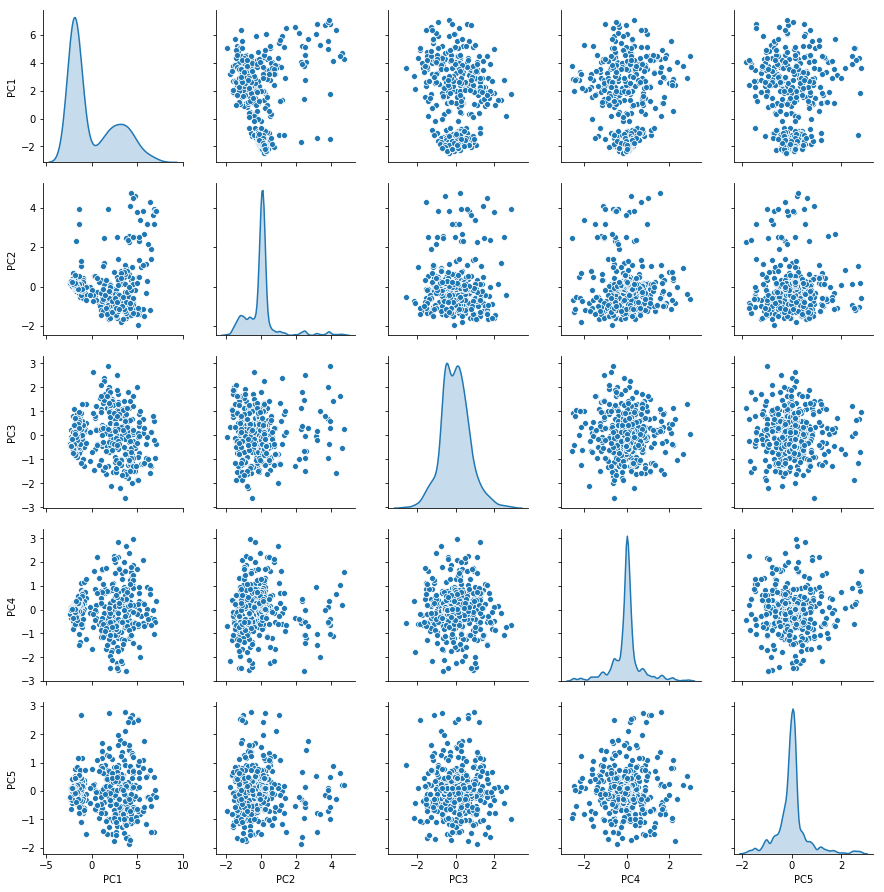

In [39]:
sns.pairplot(principalDf,diag_kind= 'kde',palette="husl")